Filename: m101.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     125   (530, 530)   int16   
  1  Photometric CALTABLE    1 BinTableHDU     39   16R x 4C   [1D, 1D, 1D, 1J]   

Number of HDUs: 2
PrimaryHDU contains image data, the index is 0
Data type: >i2
First 5 header keywords:
SIMPLE  =                    T /FITS header                                     
BITPIX  =                   16 /No.Bits per pixel                               
NAXIS   =                    2 /No.dimensions                                   
NAXIS1  =                  530 /Length X axis                                   
NAXIS2  =                  530 /Length Y axis                                   
(530, 530)
Value of BITPIX: 16
yes

done, but I will it call it minifoto
Shape of data array: (530, 530)
yes
yes
 It is a NumPy data type object: int16.
yes
-----------image data---------------
Min:1507
Max:15752
Mean:4795.924268422927
Std:1848.2526085366376
M

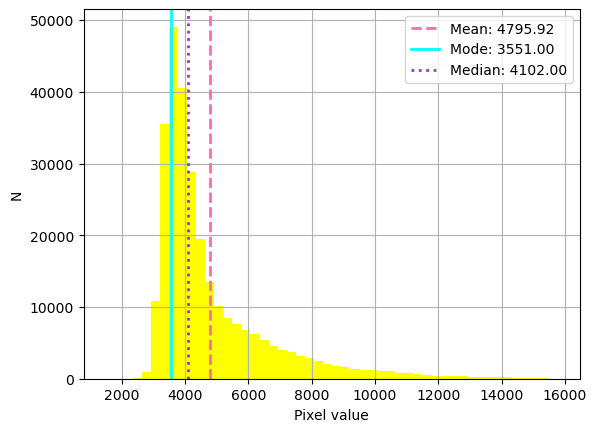

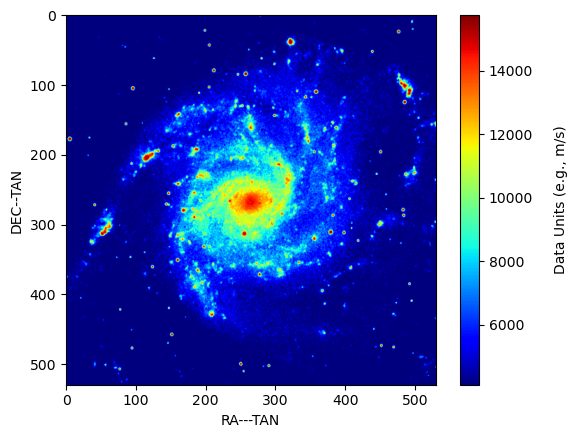

Min. and Max. values of log10(dat): 3.1781135 4.197336


 [astropy.io.fits.verify]


In [1]:
#6.1
from matplotlib.pyplot import figure, show
import numpy as np
from astropy.io import fits
from scipy import stats
import matplotlib
import matplotlib.pyplot as plt

foto = fits.open('m101.fits')
foto.info()

print()
#How many HDU’s are in this FITS file?
num_hdus = len(foto)
print(f'Number of HDUs: {num_hdus}')

#Which HDU contains the image data? What is the index of that HDU in the list?
print("PrimaryHDU contains image data, the index is 0")

#What is the number type of the data?
minifoto = foto[0].data 
print(f'Data type: {minifoto.dtype}')

#Read the header keywords and list the first 5 of them. 
hoofd = foto[0].header
print('First 5 header keywords:')
for i, card in enumerate(hoofd.cards):
    if i >= 5:
        break
    print(card)
print(minifoto.shape)
#What is the value of BITPIX=?
bitpix_value = hoofd['BITPIX']
print(f'Value of BITPIX: {bitpix_value}')

#Does it correspond with the data type found in the previous question?
print("yes")
print()
#Read the data in a variable called dat.
print("done, but I will it call it minifoto")
#What is the shape of the NumPy array dat.
print(f'Shape of data array: {minifoto.shape}')
#Does this correspond to the information returned with info()?
print("yes")
#Does it correspond to the values of the NAXIS keywords in the header?
print("yes")
#What is the contents of the attribute dtype of the array minifoto
print(" It is a NumPy data type object: int16.")
#Check online for the meaning of dtype. Does it correspond to the value in BITPIX=
print("yes")

#ind and report the following statistical properties of the (flattened, i.e. 1-dim) 
#image data: minimum, maximum, mean, standard deviation, median, mode.
plattefoto = minifoto.flatten()
print("-----------image data---------------")
print(f"Min:{np.min(plattefoto)}")
print(f"Max:{np.max(plattefoto)}")
print(f"Mean:{np.mean(plattefoto)}")
print(f"Std:{np.std(plattefoto)}")
print(f"Median:{np.median(plattefoto)}")

minimode = stats.mode(plattefoto, keepdims=False)
grotemode = minimode.mode   

print(f"Mode:{(grotemode)}") #niet helemaal sure of dit klopt

#Make a histogram of the flattened image data and use method matplotlib.axes.Axes.axvline() 
#to draw vertical lines at the positions of the mean, median and mode.
#Additionally, add labels to each line and show with legend.

fig = figure()
frame = fig.add_subplot(1,1,1)
frame.hist(plattefoto, bins=50, color="yellow")
frame.grid()
frame.set_xlabel("Pixel value")
frame.set_ylabel("N")


frame.axvline(np.mean(plattefoto), color='hotpink', linestyle='dashed', linewidth=2, label=f'Mean: {np.mean(plattefoto):.2f}')
frame.axvline(grotemode, color='aqua', linestyle='solid', linewidth=2, label=f'Mode: {minimode.mode:.2f}') # Note: minimode.mode might need indexing if it returns an array
frame.axvline(np.median(plattefoto), color='darkorchid', linestyle='dotted', linewidth=2, label=f'Median: {np.median(plattefoto):.2f}')

frame.legend()

#Convert the imaging data into floating point numbers with np.asarray(), and plot the image data.
#Calculate the median of the data and use it as the cutoff in vmin.
fig = figure()
frame = fig.add_subplot(1,1,1)
vliegendefoto = np.asarray(minifoto, dtype=float)
median_vf= np.median(vliegendefoto)
picca=plt.imshow(vliegendefoto, cmap="jet", vmin=median_vf)

#Label the axes with the values in keywords CTYPE1 and CTYPE2.
plt.xlabel(hoofd['CTYPE1'])
plt.ylabel(hoofd['CTYPE2'])

#Add a locatable colorbar (from week 5 material).
kleurtjes=plt.colorbar(picca)

#Add a label to the color bar to show the data units.
kleurtjes.set_label('Data Units (e.g., m/s)', rotation=90, labelpad=15)

plt.show()

#Add a new keyword BUNIT to the header and give it the value “Counts”. 
#Then, write the floating point version of your image data to a new FITS file. 
#Check the FITS Notebook for how to ignore messages about invalid header keywords.
hoofd['BUNIT'] = 'Counts'
hoofd = foto[0].header

logdat = np.log10(minifoto)
print("Min. and Max. values of log10(dat):", logdat.min(), logdat.max())

stoutefoto = fits.PrimaryHDU(logdat)
stoutefoto.header = hoofd    
stoutefoto.writeto('stoutefoto.fits', overwrite=True, output_verify='ignore')



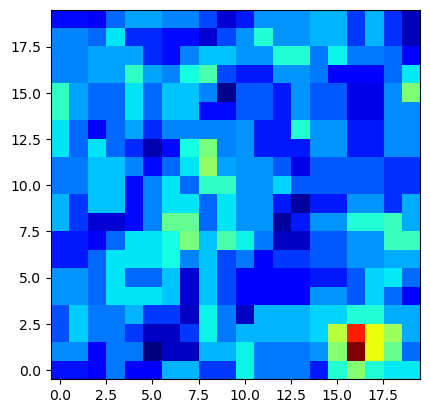

6987.38
83.59054970509526
 Mean: 3493.69
 STD: 320.9677069426144


In [2]:
#6.3
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import math
#Find a rectangular area (e.g. 20x20 pixels) in the image of m101.fits where is noise background. 
#Inspect an image with either imshow() or ds9. For your own device, ds9 can be downloaded from saoimageds9
#Define a slice for that area and extract the data.

Flip = fits.open('m101.fits')
lievefoto = Flip[0].data.astype(float)   
ruis = lievefoto[30:50, 30:50]
plt.imshow(ruis, cmap='jet', origin='lower')
plt.show()

#What is the RMS in your selected area?
gemene_ruis = np.mean((ruis*2))
print(gemene_ruis)

X_rms = math.sqrt(gemene_ruis)
print(X_rms)

#What is the mean and standard deviation of these pixels?
print(f" Mean: {np.mean(ruis)}")
print(f" STD: {np.std(ruis)}")
      


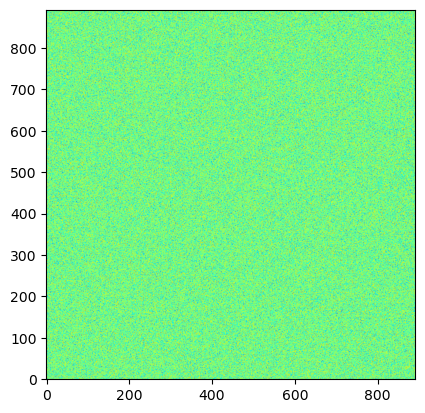

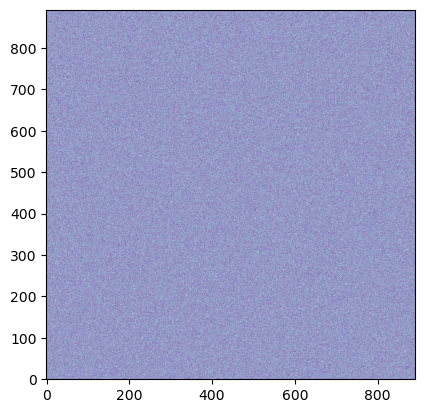

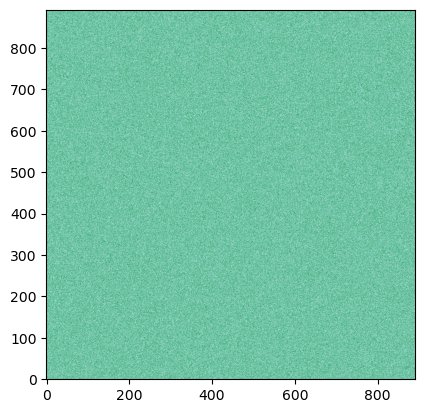

STD nootje: 10.003955116338458
STD cadeautje: 10.003955116338458
STD floatje: 10.003955116338458
[[ -1.55630098  -1.82591114 -30.13095337 ...   9.5304864   -3.1976514
   -9.56535454]
 [  5.36767418   6.08811474 -12.64769598 ... -16.89080103   3.45191898
   -0.17180363]
 [  4.3463451   23.93604102   6.62419659 ...   6.94069744 -16.05502778
   -7.77582347]
 ...
 [-22.97836153  11.55492042 -11.12176605 ...  14.01001642  -1.5138498
    7.91289786]
 [ 18.04804039 -11.8455741    7.69821443 ...   0.75319522  -9.93377406
    2.14823115]
 [ -0.55804758   2.41444124  18.97043134 ...   1.25109864 -13.84704095
   12.89765364]]
standaardruis: 10.003955116338458
not standaardruis and it is not the same:5.775786179378943 


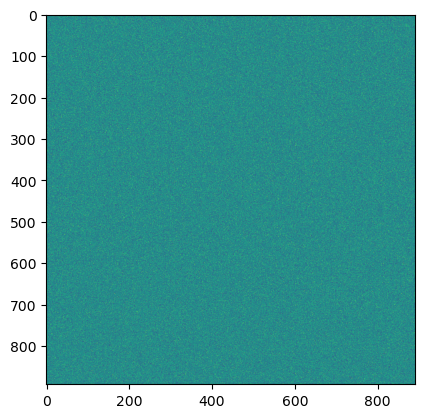

In [3]:
#Question 6.5 
from astropy.io import fits

#Download noisemap0.fits, noisemap1.fits and noisemap2.fits. These are all images which only contain noise.
ruiz_met_een_z = fits.open('noisemap1.fits')
guis_met_een_g  = fits.open('noisemap1.fits')
roos_met_een_oo  = fits.open('noisemap1.fits')

nootje = ruiz_met_een_z[0].data.astype(float)   
cadeautje = guis_met_een_g[0].data.astype(float) 
floatje = roos_met_een_oo[0].data.astype(float) 

fig = figure()
plt.imshow(nootje, cmap='jet', origin='lower')
fig = figure()
plt.imshow(cadeautje, cmap='BuPu', origin='lower')
fig = figure()
plt.imshow(floatje, cmap='BuGn', origin='lower')
plt.show()

#Calculate the standard deviation in each of these images.

std_nootje = np.std(nootje)
print(f"STD nootje: {std_nootje}")
std_cadeautje = np.std(cadeautje)
print(f"STD cadeautje: {std_cadeautje}")
std_floatje = np.std(floatje)
print(f"STD floatje: {std_floatje}")

#Stack the images in a 3D structure with numpy.stack() in the Z direction.
gestapelderuis = np.stack([nootje, cadeautje, floatje], axis=0)

#Use np.mean(axis=n) to create an image which is the mean of the three images. 
#n is the integer that sets the direction in which the mean is calculated.
print(np.mean(gestapelderuis, axis=0))
gemenegestapelderuis= np.mean(gestapelderuis, axis=0)
figure()
plt.imshow(gemenegestapelderuis)

#Calculate the standard deviation for all pixels in this mean image.
standaardruis = np.std(gemenegestapelderuis)
print(f'standaardruis: {standaardruis}')

#Does the standard deviation corresponds to the one we calculate with:
stom = ((std_nootje**2)+(std_cadeautje**2)+(std_floatje**2))
leuk = (math.sqrt(stom))/3
print(f"not standaardruis and it is not the same:{leuk} ")


In [2]:
#6.6
from astropy.io import fits
from astropy.table import Table  
import numpy as np

sterren = fits.open('APOGEE_stars.fits')
sterrendata = sterren[1].data 
sterrencolnames = sterren[1].columns.names 
sterren_table = Table(sterren[1].data) 

cond1 = sterren_table['STARFLAG'] == 0
cond2 = sterren_table['ASPCAPFLAG'] == 0
cond3 = sterren_table['SNR'] > 10
cond4 = (sterren_table['GAIAEDR3_PARALLAX'] / sterren_table['GAIAEDR3_PARALLAX_ERROR']) > 5
cond5 = ~np.isnan(sterren_table['GAIAEDR3_PHOT_G_MEAN_MAG'])
cond6 = ~np.isnan(sterren_table['GAIAEDR3_PHOT_BP_MEAN_MAG'])
cond7 = ~np.isnan(sterren_table['GAIAEDR3_PHOT_RP_MEAN_MAG'])

sterrenfilter = cond1 & cond2 & cond3 & cond4 & cond5 & cond6 & cond7
sterren_table['DATAFLAG'] = sterrenfilter.astype(int)

m_G = sterren_table['GAIAEDR3_PHOT_G_MEAN_MAG']
parallax = sterren_table['GAIAEDR3_PARALLAX']

safe_parallax = np.where(parallax > 0, parallax, 1.0)
absolute_mag = m_G + 5 * np.log10(safe_parallax / 1000) + 5
sterren_table['ABS_MAG_G'] = absolute_mag
sterren_table['ABS_MAG_G'][sterren_table['DATAFLAG'] == 0] = -1.0

sterren_table.write('APOGEE_update.fits', format='fits', overwrite=True)

sterren.close()

Row with maximum phot_g_mean_flux     source_id         ra  ra_error       dec  dec_error  phot_g_mean_flux  \
64   17418337  235.84286  0.005008  11.71101    0.00445        42489404.0   

    phot_g_mean_flux_error  phot_g_mean_mag  phot_bp_mean_flux  \
64                5649.703         6.617699         15722506.0   

    phot_bp_mean_flux_error  phot_bp_mean_mag  phot_rp_mean_flux  \
64                 9947.167          7.360095         31655918.0   

    phot_rp_mean_flux_error  phot_rp_mean_mag  a_g_val  e_bp_min_rp_val  
64                20056.184          6.010764      0.0              0.0  




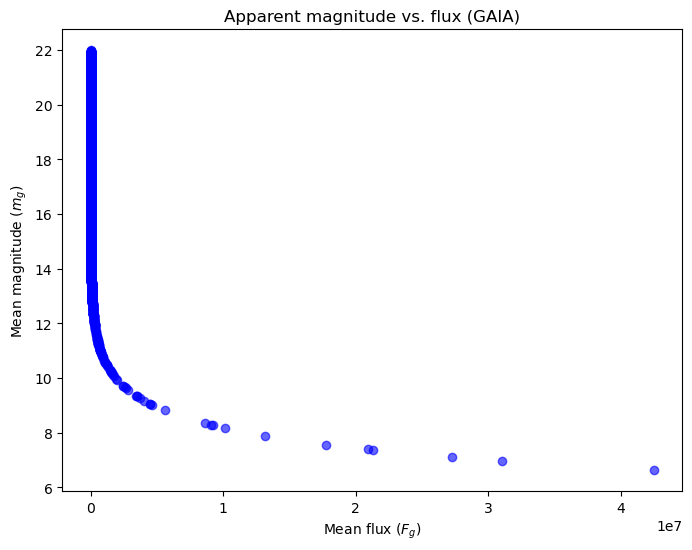

The average calculated value for m_0 is: 25.6884


In [3]:
#6.7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

gaiadata = pd.read_csv('gaiaTestData.csv')
max_flux_index = gaiadata['phot_g_mean_flux'].idxmax()
max_flux_row = gaiadata.loc[[max_flux_index]]

print('Row with maximum phot_g_mean_flux', max_flux_row)
print("\n")


fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(gaiadata['phot_g_mean_flux'], gaiadata['phot_g_mean_mag'], alpha=0.6, color='blue')
ax.set_xlabel('Mean flux ($F_g$)')
ax.set_ylabel('Mean magnitude ($m_g$)')
ax.set_title('Apparent magnitude vs. flux (GAIA)')
plt.show()

m_0_values = gaiadata['phot_g_mean_mag'] + 2.5 * np.log10(gaiadata['phot_g_mean_flux'])
m_0_average = m_0_values.mean()

print(f"The average calculated value for m_0 is: {m_0_average:.4f}")

Query the following columns of random 50 data from GAIA DR3, satisfying the selection criteria:
Requested columns: source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
Selection criteria 
GAIAEDR3_PARALLAX/ GAIAEDR3_PARALLAX_ERROR > 5
GAIAEDR3_PHOT_G_MEAN_MAG is not empty
GAIAEDR3_PHOT_BP_MEAN_MAG is not empty
GAIAEDR3_PHOT_RP_MEAN_MAG is not empty

Create Pandas DataFrame of your retrieval. 
Output a FITS file called "astroquery_gaia.fits"

In [8]:
#6.10
from astroquery.gaia import Gaia
import pandas as pd

kwak = """
SELECT TOP 50 source_id, ra, dec, parallax, parallax_error, phot_g_mean_mag, phot_bp_mean_mag, phot_rp_mean_mag
FROM gaiadr3.gaia_source
WHERE parallax / parallax_error > 5 
AND phot_g_mean_mag IS NOT NULL
AND phot_bp_mean_mag IS NOT NULL
AND phot_rp_mean_mag IS NOT NULL
ORDER BY random_index
"""

kwik = Gaia.launch_job(kwak)
results = kwik.get_results()
kwek = results.to_pandas()


print(results)
print(kwek.head())

results.write('astroquery_gaia.fits', format='fits', overwrite=True)

     source_id              ra         ... phot_bp_mean_mag phot_rp_mean_mag
                           deg         ...       mag              mag       
------------------- ------------------ ... ---------------- ----------------
4267180339403392768  286.7169128963743 ...        15.942071        14.419943
6709252873623174016     276.6911939192 ...        16.380306        15.151749
4040949706019490560 265.22936348434496 ...        16.118845        13.680644
4517539583701880064 284.02566215626837 ...        16.652264        15.347014
1823532754729083392 300.80580445460237 ...        14.782262        13.795675
3586362911238437248 171.80987737943448 ...        14.809981        12.990531
2220802729771409024  320.3998716199124 ...        17.259604        15.978823
5850180760683762688  205.6911379853152 ...         18.26916        17.014418
2128624652762622080  294.2962728879645 ...        19.113455        17.192604
                ...                ... ...              ...              ...

In [7]:
#6.14
class Fibonacci:
    def __init__(self):
        self.sequence = [0, 1]

    def get_nth_term(self, n):
        for _ in range(len(self.sequence), n + 1):
            next_number = self.sequence[-1] + self.sequence[-2]
            self.sequence.append(next_number)
        return self.sequence[n]

    def get_divisible_less_than_nth(self, n, m):
        self.get_nth_term(n)
        results = []
        for number in self.sequence[:n]:
            if number % m == 0 and number not in results:
                results.append(number)
        return results


fibbie = Fibonacci()


print(f'term 100 in Fibbie: {fibbie.get_nth_term(100)}')
print(fibbie.get_divisible_less_than_nth(100, 7))

term 100 in Fibbie: 354224848179261915075
[0, 21, 987, 46368, 2178309, 102334155, 4807526976, 225851433717, 10610209857723, 498454011879264, 23416728348467685, 1100087778366101931, 51680708854858323072]
